# Sparse Chebyshev Models for Factorable Functions

Similar to Taylor models ([Neumaier, 2002](https://doi.org/10.1023/A:1023061927787)), Chebyshev models ([Dzetkulič, 2015](https://doi.org/10.1007/s11075-014-9889-x); [Rajyaguru et al., 2016](https://doi.org/10.1007/s10898-016-0474-9)) are estimators made by the sum of a multivariate polynomial in Chebyshev form and a remainder interval providing a bound on the approximation error. Formally, given the continuous function $f:\mathbf{X}\to\mathbb{R}$ on the interval domain $\mathbf{X}\in\mathbb{IR}^n$, a $q$th-order Chebyshev model of $f$ on $\mathbf{X}$ is any pair $(\mathcal{P}_{f,\mathbf{X}}^{q},\mathcal{R}_{f,\mathbf{X}}^{q})$, where $\mathcal{P}_{f,\mathbf{X}}^{q}:[-1,1]^n\to\mathbb{R}$ with $\mathcal{P}_{f,\mathbf{X}}^{q}(\boldsymbol{\xi}) \coloneqq \sum_{|\kappa|\leq q} a_\kappa T_\kappa(\boldsymbol{\xi})$ is a polynomial approximant of degree $q$, and $\mathcal{R}_{f,\mathbf{X}}^{q}\in\mathbb{IR}$ is a symmetric interval such that
\begin{align}
\forall \boldsymbol{\xi}\in[-1,1]^n, \quad f(\text{mid} \mathbf{X} +\boldsymbol{\xi}\circ\text{rad} \mathbf{X}) - \mathcal{P}_{f,\mathbf{X}}^{q}(\boldsymbol{\xi}) \in \mathcal{R}_{f,\mathbf{X}}^{q}
\end{align}
with $\circ$ denoting the Hadamard product. It is worth noting that the polynomial part $\mathcal{P}_{f,\mathbf{X}}^{q}$ of a Chebyshev model is in general different from the actual truncated Chebyshev expansion of $f$. Notice also the need for scaling the variables in $[-1,1]$ for consistency with the definition and properties of Chebyshev polynomials of the first kind.

The modules `SCModel` and `SCVar` in PyMC provide a means of computing such sparse Chebyshev models for multivariate factorable functions on interval domains $\mathbf{X}\in\mathbb{IR}^n$. The counterpart modules `CModel` and `CVar` are for computing dense Chebyshev models (cf. [Other notebook](./cmodel.ipynb)). 

## Computing Sparse Chebyshev Models in PyMC

Suppose we want to compute a sparse, 4th-order Chebyshev model of the real-valued function $f(x,y)=x(\exp(x)-y)^2$ for $(x,y)\in [-2,1]\times[-1,2]$. 

We start by importing the PyMC library:

In [1]:
import pymcpp

We proceed by defining the environment for 4th-order Chebyshev model. We then define the ranges of both variables $x$ and $y$ (cf. [Other notebook](./interval.ipynb)) and initialize spectral bound variables for $x$ and $y$ of type `pymcpp.SCVar` with indices `0` and `1`, respectively:

In [2]:
xI, yI = pymcpp.Interval(-2,1), pymcpp.Interval(-1,2)
Q = 4
env = pymcpp.SCModel(Q)
xSC, ySC = pymcpp.SCVar( env, 0, xI ), pymcpp.SCVar( env, 1, yI )
#print(xSC, ySC)

In [3]:
def f( x, y ):
    return x*(np.exp(x)-y)**2
    #return 1.+x-np.sin(2.*x+3.*y)-np.cos(3.*x-5.*y)

def fSC( x, y ):
    return x*(pymcpp.exp(x)-y)**2
    #return 1.+x-pymcpp.sin(2.*x+3.*y)-pymcpp.cos(3.*x-5.*y)


With operator overloading, we can simply compute a sparse Chebyshev model of $f(x,y)$ on $[-2,1]\times[-1,2]$ as:

In [4]:
zSC = fSC( xSC, ySC )
print( "Sparse Chebyshev model:", zSC )

Sparse Chebyshev model: 
 2.0253533e-01   0  1
 3.3301859e+00   1  T1[0]
-1.9311667e+00   1  T1[1]
 1.1230009e+00   2  T2[0]
-1.3803955e+00   2  T1[0]·T1[1]
-5.6250000e-01   2  T2[1]
 7.9187832e-01   3  T3[0]
-2.2850792e+00   3  T2[0]·T1[1]
 1.6875000e+00   3  T1[0]·T2[1]
 3.4617226e-01   4  T4[0]
-7.7511390e-01   4  T3[0]·T1[1]
   R     =  [-6.8562421e-01, 6.8562421e-01]
   B     =  [-1.2600327e+01, 1.3998742e+01]



A dictionary of monomials and corresponding coefficients and a set of participating variables can be retrieved as:

In [5]:
print( zSC.coefmon )
print( zSC.ndxvar )

{1: 0.20253533070260277, [0]: 3.3301859232425204, [1]: -1.931166652019295, [0]^2: 1.1230009184570646, [0]·[1]: -1.3803954549940736, [1]^2: -0.5625, [0]^3: 0.7918783206490221, [0]^2·[1]: -2.285079188101786, [0]·[1]^2: 1.6875, [0]^4: 0.34617225795936885, [0]^3·[1]: -0.7751139009038267}
{0, 1}


Sparse Chebyshev models bounds can also be propagated through an expression tree (DAG):

In [6]:
DAG  = pymcpp.FFGraph()
X, Y = DAG.add_var( "x" ), DAG.add_var( "y" )

F = fSC( X, Y )
print( "f(", X.str(), ",", Y.str(), ") = ", F.str() )

[zSC2] = DAG.eval( [F], [X,Y], [xSC,ySC] )
print("Sparse Chebyshev model:", zSC2)

f( x , y ) =  x * SQR( EXP( x ) - y )
Sparse Chebyshev model: 
 2.0253533e-01   0  1
 3.3301859e+00   1  T1[0]
-1.9311667e+00   1  T1[1]
 1.1230009e+00   2  T2[0]
-1.3803955e+00   2  T1[0]·T1[1]
-5.6250000e-01   2  T2[1]
 7.9187832e-01   3  T3[0]
-2.2850792e+00   3  T2[0]·T1[1]
 1.6875000e+00   3  T1[0]·T2[1]
 3.4617226e-01   4  T4[0]
-7.7511390e-01   4  T3[0]·T1[1]
   R     =  [-6.8562421e-01, 6.8562421e-01]
   B     =  [-1.2600327e+01, 1.3998742e+01]



A 3d plot showing the resulting estimators of the function $f$ over the domain $[-2,1]\times[-1,2]$ is shown below. 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

M = 128
mat_x = np.outer(np.linspace(xI.l, xI.u, M), np.ones(M))
mat_y = np.outer(np.ones(M), np.linspace(yI.l, yI.u, M))

In [8]:
mat_f   = np.ndarray(shape=(M,M))
mat_fl  = np.outer(np.ones(M), np.ones(M)) * zSC.B.l
mat_fu  = np.outer(np.ones(M), np.ones(M)) * zSC.B.u

mat_fun = np.ndarray(shape=(M,M))
mat_fov = np.ndarray(shape=(M,M))

for i,j in product(range(M),range(M)):
    [mat_f[i,j]] = DAG.eval( [F], [X,Y], [mat_x[i,j],mat_y[i,j]] )
    Pf = zSC.P( {0: mat_x[i,j], 1: mat_y[i,j]} )
    mat_fun[i,j] = Pf + zSC.R.l
    mat_fov[i,j] = Pf + zSC.R.u

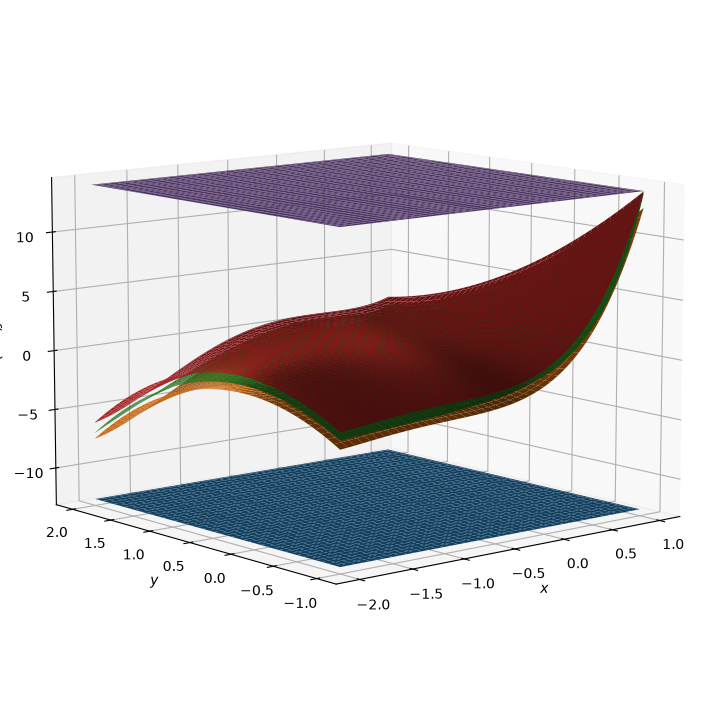

In [9]:
fig = plt.figure(figsize =(14, 9))
ax = plt.axes(projection ='3d')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')

ax.plot_surface(mat_x, mat_y, mat_fl)
ax.plot_surface(mat_x, mat_y, mat_fun)
ax.plot_surface(mat_x, mat_y, mat_f)
ax.plot_surface(mat_x, mat_y, mat_fov)
ax.plot_surface(mat_x, mat_y, mat_fu)
ax.view_init(elev=10, azim=230)

plt.show()

We can recover a sparse Chebyshev polynomial as a `pymcpp.SPoly` variable, from the polynomial part of any sparse Chebyshev model as follows:

In [11]:
pymcpp.SPoly.options.BASIS = pymcpp.SPoly.options.CHEB
zSP = pymcpp.SPoly( zSC.coefmon )
print( zSP )

2.02535e-01 + 3.33019e+00 T1[0] - 1.93117e+00 T1[1] + 1.12300e+00 T2[0] - 1.38040e+00 T1[0]·T1[1] - 5.62500e-01 T2[1] + 7.91878e-01 T3[0] - 2.28508e+00 T2[0]·T1[1] + 1.68750e+00 T1[0]·T2[1] + 3.46172e-01 T4[0] - 7.75114e-01 T3[0]·T1[1]
